In [1]:
# Cell 1 — GPU / PyTorch sanity check
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv,noheader
!free -h | head -2
import torch
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

NVIDIA A100-SXM4-80GB, 81920 MiB, 0 MiB
               total        used        free      shared  buff/cache   available
Mem:           167Gi       986Mi       162Gi       2.0Mi       3.5Gi       164Gi
PyTorch: 2.10.0+cu128  |  CUDA: True


In [1]:
# Cell 2 — Mount Drive, set project dir
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/STAT8240_EPA_Project'
for sub in ['results', 'embeddings', 'checkpoints', 'logs', 'kaggle']:
    os.makedirs(f'{PROJECT_DIR}/{sub}', exist_ok=True)

print(f'✓ Project dir: {PROJECT_DIR}')
print(f'  Existing runs.jsonl: {os.path.exists(f"{PROJECT_DIR}/results/runs.jsonl")}')
print(f'  GPT-2 embedding cache: {os.path.exists(f"{PROJECT_DIR}/embeddings/EPA-Air")}')
print(f'  Kaggle creds: {os.path.exists(f"{PROJECT_DIR}/kaggle/kaggle.json")}')

Mounted at /content/drive
✓ Project dir: /content/drive/MyDrive/STAT8240_EPA_Project
  Existing runs.jsonl: True
  GPT-2 embedding cache: True
  Kaggle creds: True


In [2]:
# Cell 3 — Clone Time-IMM + IMM-TSF (same as April-16)
%cd /content
!rm -rf Time-IMM IMM-TSF
!git clone -q https://github.com/blacksnail789521/Time-IMM.git
!git clone -q https://github.com/blacksnail789521/IMM-TSF.git
!ls

/content
drive  IMM-TSF	sample_data  Time-IMM


In [3]:
# Cell 4 — Pin torch version and install IMM-TSF deps
!pip install -q torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 \
    --index-url https://download.pytorch.org/whl/cu126 2>&1 | tail -3

%cd /content/IMM-TSF
!pip install -q -r requirements.txt 2>&1 | tail -3
%cd /content

import torch
print(f'Torch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 146.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 123.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.5/156.5 MB 16.5 MB/s eta 0:00:00
/content/IMM-TSF
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 122.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
/content
Torch: 2.7.0+cu126  |  CUDA: True


In [4]:
# Cell 5 — Poster-ready matplotlib style
import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE = {
    'primary':   '#065A82',  # deep teal
    'secondary': '#1C7293',  # teal
    'accent':    '#21295C',  # midnight navy
    'warm':      '#B85042',  # terracotta (text-hurts)
    'cool':      '#2C5F2D',  # forest (text-helps)
    'neutral':   '#6B7280',  # cool gray
    'bg':        '#FFFFFF',
    'grid':      '#E5E7EB',
}
mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#4B5563', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': PALETTE['grid'], 'grid.linewidth': 0.6,
    'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelsize': 11, 'axes.labelcolor': '#374151',
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'xtick.color': '#4B5563', 'ytick.color': '#4B5563',
    'legend.frameon': False, 'legend.fontsize': 10,
    'font.family': 'DejaVu Sans',
    'savefig.dpi': 200, 'savefig.bbox': 'tight',
})
print('✓ Poster palette applied')

✓ Poster palette applied


In [5]:
# Cell 6 — Restore data folder + GPT-2 embeddings from Drive cache
import os, shutil
from pathlib import Path

EPA_PATH = '/content/IMM-TSF/data/EPA-Air'
EMB_CACHE_DIR = f'{PROJECT_DIR}/embeddings/EPA-Air'
EPA_PROCESSED = '/content/IMM-TSF/data/EPA-Air/processed'

# --- Step 1: get the data folder in place
if os.path.exists(EPA_PATH):
    print(f'✓ Data already present at {EPA_PATH}')
else:
    print('Downloading TIME-IMM from Kaggle...')
    os.makedirs('/content/IMM-TSF/data', exist_ok=True)

    # Set up kaggle creds from Drive
    KAGGLE_DRIVE = f'{PROJECT_DIR}/kaggle/kaggle.json'
    if os.path.exists(KAGGLE_DRIVE):
        os.makedirs('/root/.kaggle', exist_ok=True)
        shutil.copy(KAGGLE_DRIVE, '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
    else:
        raise FileNotFoundError(f'No kaggle.json at {KAGGLE_DRIVE}')

    %cd /content/IMM-TSF/data
    !kaggle datasets download -d blacksnail789521/time-imm -q
    !unzip -q time-imm.zip
    !rm time-imm.zip
    %cd /content
    print('✓ Download complete')

print('\nEPA-Air counties present:')
!ls /content/IMM-TSF/data/EPA-Air/processed/

# --- Step 2: restore cached GPT-2 embeddings
cached_pts = list(Path(EMB_CACHE_DIR).rglob('*.pt')) if os.path.exists(EMB_CACHE_DIR) else []

if cached_pts:
    print(f'\n✓ Found {len(cached_pts)} cached GPT-2 embedding file(s) — restoring')
    for pt in cached_pts:
        county = pt.parent.name
        dst = Path(EPA_PROCESSED) / county / pt.name
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(pt, dst)
    print('✓ Restored to data dir')
    # Verify
    restored = list(Path(EPA_PROCESSED).rglob('text_embeddings*.pt'))
    print(f'  Embedding files in live data dir: {len(restored)}')
else:
    raise FileNotFoundError(
        f'No cached embeddings at {EMB_CACHE_DIR}. '
        'Re-run the GPT-2 embedding cell (Cell 11) from the April-16 notebook first.'
    )

/content/IMM-TSF/data
Dataset URL: https://www.kaggle.com/datasets/blacksnail789521/time-imm
License(s): Attribution 4.0 International (CC BY 4.0)
/content
✓ Download complete

EPA-Air counties present:
Bexar	Denver	      Los_Angeles  Philadelphia
Dallas	Hillsborough  Maricopa	   Richmond

✓ Found 8 cached GPT-2 embedding file(s) — restoring
✓ Restored to data dir
  Embedding files in live data dir: 8


In [6]:
# Cell 7 — Apply per-county evaluation patches to IMM-TSF
import shutil, py_compile
from pathlib import Path

REPO = Path('/content/IMM-TSF')

# ---------- Patch 1: lib/parse_datasets.py ----------
p1 = REPO / 'lib' / 'parse_datasets.py'
shutil.copy(p1, str(p1) + '.bak')
src = p1.read_text()

old1 = ('            numeric_batch = [item[:4] for item in batch]\n'
        '            out = base_collate(numeric_batch, args, time_max)')
new1 = ('            numeric_batch = [item[:4] for item in batch]\n'
        '            chunk_ids_batch = [item[0] for item in batch]  # per-county eval patch\n'
        '            out = base_collate(numeric_batch, args, time_max)\n'
        '            out["chunk_ids"] = chunk_ids_batch  # per-county eval patch')

assert src.count(old1) == 1, f'Patch 1 anchor not unique (count={src.count(old1)})'
p1.write_text(src.replace(old1, new1))
py_compile.compile(str(p1), doraise=True)
print('✓ Patch 1 applied to lib/parse_datasets.py')

# ---------- Patch 2: lib/evaluation.py ----------
p2 = REPO / 'lib' / 'evaluation.py'
shutil.copy(p2, str(p2) + '.bak')
src = p2.read_text()

# 2a: init per-county accumulators right after mape init
old2a = '    total_results["mape"] = 0\n'
new2a = ('    total_results["mape"] = 0\n'
         '    # --- per-county eval patch: init accumulators ---\n'
         '    per_county_se = {}\n'
         '    per_county_mask = {}\n')
assert src.count(old2a) == 1, f'Patch 2a anchor not unique (count={src.count(old2a)})'
src = src.replace(old2a, new2a, 1)

# 2b: inside eval loop, accumulate per-sample SE grouped by county
old2b = ('        # (n_dim, ) , (n_dim, )\n'
         '        se_var_sum, mask_count = compute_error(')
new2b = (
    '        # --- per-county eval patch: accumulate per-sample SE by county ---\n'
    '        _pred_y_3d = pred_y.squeeze(0) if pred_y.dim() == 4 else pred_y\n'
    '        _truth = batch_dict["data_to_predict"]\n'
    '        _mpd = batch_dict["mask_predicted_data"]\n'
    '        _se_bd = (((_truth - _pred_y_3d) ** 2) * _mpd).sum(dim=1).detach().cpu()  # [B, D]\n'
    '        _mk_bd = _mpd.sum(dim=1).detach().cpu()  # [B, D]\n'
    '        for _i, _cid in enumerate(batch_dict.get("chunk_ids", [])):\n'
    '            _cnty = _cid.rsplit("_chunk", 1)[0]\n'
    '            if _cnty not in per_county_se:\n'
    '                per_county_se[_cnty] = _se_bd[_i].clone()\n'
    '                per_county_mask[_cnty] = _mk_bd[_i].clone()\n'
    '            else:\n'
    '                per_county_se[_cnty] += _se_bd[_i]\n'
    '                per_county_mask[_cnty] += _mk_bd[_i]\n'
    '\n'
    '        # (n_dim, ) , (n_dim, )\n'
    '        se_var_sum, mask_count = compute_error(')
assert src.count(old2b) == 1, f'Patch 2b anchor not unique (count={src.count(old2b)})'
src = src.replace(old2b, new2b, 1)

# 2c: finalize per-county MSE and emit as JSON string in return dict
old2c = '    for key, var in total_results.items():\n'
new2c = (
    '    # --- per-county eval patch: finalize (same aggregation as pooled MSE) ---\n'
    '    import json as _json\n'
    '    per_county_mse = {}\n'
    '    for _cnty, _se_d in per_county_se.items():\n'
    '        _mk_d = per_county_mask[_cnty]\n'
    '        _avg_per_dim = _se_d / (_mk_d + 1e-8)\n'
    '        _n_avai = int((_mk_d > 0).sum().item())\n'
    '        if _n_avai > 0:\n'
    '            per_county_mse[_cnty] = float((_avg_per_dim.sum() / _n_avai).item())\n'
    '    total_results["per_county_mse_json"] = _json.dumps(per_county_mse, sort_keys=True)\n'
    '\n'
    '    for key, var in total_results.items():\n'
)
assert src.count(old2c) == 1, f'Patch 2c anchor not unique (count={src.count(old2c)})'
src = src.replace(old2c, new2c, 1)

p2.write_text(src)
py_compile.compile(str(p2), doraise=True)
print('✓ Patch 2 applied to lib/evaluation.py')
print('✓ Both files compile — patches are safe to run')

✓ Patch 1 applied to lib/parse_datasets.py
✓ Patch 2 applied to lib/evaluation.py
✓ Both files compile — patches are safe to run


In [7]:
# Cell 8 — run_model_pc: captures per-county MSE alongside the pooled metrics
import subprocess, re, json, time
from datetime import datetime
from pathlib import Path

RESULTS_FILE = f'{PROJECT_DIR}/results/runs_percounty.jsonl'
LOGS_DIR = f'{PROJECT_DIR}/logs'
Path(LOGS_DIR).mkdir(parents=True, exist_ok=True)

DEFAULT_CONFIG = {
    'dataset': 'EPA-Air',
    'data_root': '/content/IMM-TSF/data',
    'history': 7, 'pred_window': 7, 'stride': 7,
    'time_unit': 'days', 'split_method': 'sample',
    'seed': 42, 'gpu': 0,
    'batch_size': 8, 'lr': '1e-3',
    'epoch': 50, 'patience': 10,
}
DEFAULT_MULTI = {
    'TTF_module': 'TTF_RecAvg',
    'MMF_module': 'MMF_GR_Add',
    'llm_model_fusion': 'GPT2',
}


def parse_output(stdout):
    """Extract final mse/mae and per-county MSE dict from main.py stdout."""
    out = {'mse': None, 'mae': None, 'per_county_mse': None}
    mse_matches = re.findall(r'^mse:\s*([\d.]+)', stdout, flags=re.MULTILINE)
    mae_matches = re.findall(r'^mae:\s*([\d.]+)', stdout, flags=re.MULTILINE)
    if mse_matches: out['mse'] = float(mse_matches[-1])
    if mae_matches: out['mae'] = float(mae_matches[-1])
    # The new field, printed as `per_county_mse_json: {...}` by print_formatted_dict
    pc_matches = re.findall(r'^per_county_mse_json:\s*(\{.*\})', stdout, flags=re.MULTILINE)
    if pc_matches:
        try:
            out['per_county_mse'] = json.loads(pc_matches[-1])
        except json.JSONDecodeError as e:
            print(f'   ⚠ Failed to parse per-county JSON: {e}')
    return out


def run_model_pc(model, mode='uni', notes='', show_tail=True, **overrides):
    cfg = {**DEFAULT_CONFIG, 'model': model, **overrides}
    cmd = ['python', 'main.py']
    for k, v in cfg.items():
        cmd += [f'--{k}', str(v)]
    if mode == 'multi':
        cmd += ['--enable_text', '--use_text_embeddings']
        for k, v in DEFAULT_MULTI.items():
            cmd += [f'--{k}', str(v)]

    print(f'▶ {model} ({mode})')
    t0 = time.time()
    proc = subprocess.run(cmd, cwd='/content/IMM-TSF',
                          capture_output=True, text=True, timeout=3600)
    elapsed = time.time() - t0

    log_name = f'{model}_{mode}_percounty_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log'
    log_path = Path(LOGS_DIR) / log_name
    log_path.write_text(f'CMD: {" ".join(cmd)}\n\n=== STDOUT ===\n{proc.stdout}'
                        f'\n\n=== STDERR ===\n{proc.stderr}')

    if proc.returncode != 0:
        print(f'   ✗ FAILED ({elapsed:.0f}s, exit={proc.returncode}) — see {log_name}')
        if show_tail:
            print('\n'.join('   ' + l for l in proc.stderr.splitlines()[-25:]))
        return None

    res = parse_output(proc.stdout)
    if res['mse'] is not None:
        pc = res['per_county_mse'] or {}
        pc_str = f'  per-county: {len(pc)}' if pc else '  ⚠ no per-county'
        print(f'   ✓ MSE={res["mse"]:.4f}  MAE={res["mae"]:.4f}  time={elapsed:.0f}s{pc_str}')
    else:
        print(f'   ⚠ Parse failed — see {log_name}')
        if show_tail:
            print('\n'.join('   ' + l for l in proc.stdout.splitlines()[-15:]))

    entry = {
        'timestamp': datetime.now().isoformat(),
        'model': model, 'mode': mode,
        'mse': res['mse'], 'mae': res['mae'],
        'per_county_mse': res['per_county_mse'],
        'elapsed_s': round(elapsed, 1),
        'seed': cfg['seed'], 'dataset': cfg['dataset'],
        'log_file': log_name, 'notes': notes,
    }
    if mode == 'multi':
        entry.update(DEFAULT_MULTI)
    with open(RESULTS_FILE, 'a') as f:
        f.write(json.dumps(entry) + '\n')

    return entry


print(f'✓ run_model_pc ready')
print(f'  Results append to: {RESULTS_FILE}')

✓ run_model_pc ready
  Results append to: /content/drive/MyDrive/STAT8240_EPA_Project/results/runs_percounty.jsonl


In [8]:
# Cell 9 — Smoke test: one run, confirm per-county capture works end-to-end
smoke = run_model_pc('DLinear', 'uni', notes='per-county extension smoke test')

if smoke and smoke.get('per_county_mse'):
    pc = smoke['per_county_mse']
    print(f'\n✓ Per-county MSE captured for {len(pc)} counties:')
    for county, mse in sorted(pc.items(), key=lambda kv: kv[1]):
        print(f'   {county:<15} MSE = {mse:.4f}')

    # Sanity check: per-county values should roughly bracket the pooled MSE
    import numpy as np
    mses = list(pc.values())
    print(f'\nPooled MSE:    {smoke["mse"]:.4f}')
    print(f'Per-county range: [{min(mses):.4f}, {max(mses):.4f}]')
    print(f'Per-county mean:  {np.mean(mses):.4f}   (unweighted — will differ slightly from pooled)')
else:
    print('\n✗ Smoke test FAILED — do NOT run the full sweep until we fix this')
    if smoke:
        print(f'  Got entry but no per-county dict: {smoke}')

▶ DLinear (uni)
   ✓ MSE=0.5438  MAE=0.5374  time=19s  per-county: 8

✓ Per-county MSE captured for 8 counties:
   Los_Angeles     MSE = 0.2864
   Denver          MSE = 0.3007
   Hillsborough    MSE = 0.5027
   Maricopa        MSE = 0.5657
   Richmond        MSE = 0.5695
   Philadelphia    MSE = 0.7570
   Bexar           MSE = 0.7580
   Dallas          MSE = 0.8080

Pooled MSE:    0.5438
Per-county range: [0.2864, 0.8080]
Per-county mean:  0.5685   (unweighted — will differ slightly from pooled)


In [9]:
# Cell 10 — Full sweep, Phase 1: 6 standard models × 2 modes
MODELS_REGULAR = ['DLinear', 'Informer', 'PatchTST', 'TimesNet', 'TimeMixer', 'TTM']

print(f'Phase 1: {len(MODELS_REGULAR)} models × 2 modes = {len(MODELS_REGULAR)*2} runs')
print('Expected wall time: ~25 min on A100 (TimesNet is ~10 min on its own)')
print('=' * 60)

sweep_t0 = time.time()
for m in MODELS_REGULAR:
    run_model_pc(m, 'uni',   notes='per-county extension')
    run_model_pc(m, 'multi', notes='per-county extension')
    print()

print('=' * 60)
print(f'Phase 1 done in {(time.time()-sweep_t0)/60:.1f} min')

Phase 1: 6 models × 2 modes = 12 runs
Expected wall time: ~25 min on A100 (TimesNet is ~10 min on its own)
▶ DLinear (uni)
   ✓ MSE=0.5438  MAE=0.5374  time=16s  per-county: 8
▶ DLinear (multi)
   ✓ MSE=0.5090  MAE=0.5189  time=22s  per-county: 8

▶ Informer (uni)
   ✓ MSE=0.6472  MAE=0.6030  time=89s  per-county: 8
▶ Informer (multi)
   ✓ MSE=0.5937  MAE=0.5750  time=97s  per-county: 8

▶ PatchTST (uni)
   ✓ MSE=0.6297  MAE=0.5991  time=33s  per-county: 8
▶ PatchTST (multi)
   ✓ MSE=0.6797  MAE=0.6094  time=62s  per-county: 8

▶ TimesNet (uni)
   ✓ MSE=0.5888  MAE=0.5684  time=655s  per-county: 8
▶ TimesNet (multi)
   ✓ MSE=0.5755  MAE=0.5523  time=556s  per-county: 8

▶ TimeMixer (uni)
   ✓ MSE=0.6427  MAE=0.6041  time=67s  per-county: 8
▶ TimeMixer (multi)
   ✓ MSE=0.5778  MAE=0.5557  time=135s  per-county: 8

▶ TTM (uni)
   ✓ MSE=0.5820  MAE=0.5692  time=49s  per-county: 8
▶ TTM (multi)
   ✓ MSE=0.5963  MAE=0.5711  time=73s  per-county: 8

Phase 1 done in 30.9 min


In [10]:
# Cell 11 — Phase 2: tPatchGNN (patch_size=4 for EPA-Air sparsity)
print('Phase 2: tPatchGNN × 2 modes with patch_size=4')
print('Expected wall time: ~2 min')
print('=' * 60)

sweep_t0 = time.time()
run_model_pc('tPatchGNN', 'uni',   notes='per-county extension, patch_size=4', patch_size=4)
run_model_pc('tPatchGNN', 'multi', notes='per-county extension, patch_size=4', patch_size=4)
print('=' * 60)
print(f'Phase 2 done in {(time.time()-sweep_t0)/60:.1f} min')

Phase 2: tPatchGNN × 2 modes with patch_size=4
Expected wall time: ~2 min
▶ tPatchGNN (uni)
   ✓ MSE=0.7098  MAE=0.6387  time=48s  per-county: 8
▶ tPatchGNN (multi)
   ✓ MSE=0.7756  MAE=0.6723  time=55s  per-county: 8
Phase 2 done in 1.7 min


In [11]:
# Cell 12 — Build the 7-model × 8-county matrix of text-helps effects
import json, pandas as pd, numpy as np

COMPLETED_MODELS = ['DLinear', 'Informer', 'PatchTST', 'TimesNet', 'TimeMixer', 'TTM', 'tPatchGNN']

# Ingest only today's per-county-extension entries
rows = []
with open(RESULTS_FILE) as f:
    for line in f:
        r = json.loads(line)
        if r.get('notes', '').startswith('per-county extension') and r['model'] in COMPLETED_MODELS:
            rows.append(r)

# Later entries overwrite earlier (JSONL is append-only; last write wins per key)
by_key = {}
for r in rows:
    by_key[(r['model'], r['mode'])] = r

# Per-county text counts (from April-16 Cell 7 — verified against Paper Table 1)
TEXT_COUNTS = {
    'Bexar': 17, 'Dallas': 209, 'Denver': 213, 'Hillsborough': 73,
    'Los_Angeles': 222, 'Maricopa': 99, 'Philadelphia': 203, 'Richmond': 208,
}
COUNTIES = sorted(TEXT_COUNTS.keys(), key=lambda c: TEXT_COUNTS[c])
print('Counties sorted by text count (sparse → dense):')
for c in COUNTIES:
    print(f'  {c:<15} {TEXT_COUNTS[c]:>4} texts')

# Build long-form DataFrame: one row per (model, county)
records = []
for m in COMPLETED_MODELS:
    uni = by_key.get((m, 'uni'))
    multi = by_key.get((m, 'multi'))
    if not uni or not multi:
        print(f'⚠ missing runs for {m}: uni={bool(uni)} multi={bool(multi)}')
        continue
    pc_uni = uni.get('per_county_mse') or {}
    pc_multi = multi.get('per_county_mse') or {}
    for c in COUNTIES:
        if c in pc_uni and c in pc_multi:
            uni_mse = pc_uni[c]
            multi_mse = pc_multi[c]
            text_helps_pct = 100.0 * (uni_mse - multi_mse) / uni_mse   # positive = text helps
            records.append({
                'model': m, 'county': c, 'text_count': TEXT_COUNTS[c],
                'mse_uni': uni_mse, 'mse_multi': multi_mse,
                'text_helps_pct': text_helps_pct,
            })

df = pd.DataFrame(records)
print(f'\n{len(df)} rows (expected {len(COMPLETED_MODELS) * len(COUNTIES)} = 56)')

# Wide table for visual inspection
pivot = df.pivot(index='model', columns='county', values='text_helps_pct')[COUNTIES]
print('\nText-helps %% by (model × county), columns sorted sparse → dense:')
print(pivot.round(2).to_string())

Counties sorted by text count (sparse → dense):
  Bexar             17 texts
  Hillsborough      73 texts
  Maricopa          99 texts
  Philadelphia     203 texts
  Richmond         208 texts
  Dallas           209 texts
  Denver           213 texts
  Los_Angeles      222 texts

56 rows (expected 56 = 56)

Text-helps %% by (model × county), columns sorted sparse → dense:
county      Bexar  Hillsborough  Maricopa  Philadelphia  Richmond  Dallas  Denver  Los_Angeles
model                                                                                         
DLinear     18.56         -2.49     12.07         16.87      2.10    3.67   -4.16        -6.34
Informer    47.02         -0.77     -1.35         16.72     -0.15    3.24    9.17         5.38
PatchTST  -124.58         20.25     13.37         -3.69    -16.22   -8.67   11.49       -13.77
TTM       -211.02          4.65     12.25         -0.28      1.23    0.11    0.32        11.66
TimeMixer   56.17          2.52     -2.80         20.26

In [12]:
# Cell 13 — Spearman correlation + cluster-bootstrap CI (resampling counties, n=8)
from scipy import stats
import numpy as np

# Per-model Spearman (n=8 counties per model)
print('Per-model Spearman ρ (text_count vs text_helps_pct):')
print('-' * 68)
per_model_rho = {}
for m in COMPLETED_MODELS:
    sub = df[df['model'] == m]
    rho, p = stats.spearmanr(sub['text_count'], sub['text_helps_pct'])
    per_model_rho[m] = rho
    direction = ('↑ more text → text helps more' if rho > 0.1 else
                 '↓ sparser → text helps more' if rho < -0.1 else
                 '~ flat')
    print(f'  {m:<12}  ρ = {rho:+.3f}   p = {p:.3f}   {direction}')

# Pooled Spearman on all 56 points
all_x = df['text_count'].values
all_y = df['text_helps_pct'].values
rho_pooled, p_pooled = stats.spearmanr(all_x, all_y)

# Cluster-bootstrap over counties (accounts for repeated-county structure of the 56 points)
rng = np.random.default_rng(42)
B = 2000
boot_rhos = []
for _ in range(B):
    sampled = rng.choice(COUNTIES, size=len(COUNTIES), replace=True)
    sub = pd.concat([df[df['county'] == c] for c in sampled], ignore_index=True)
    if sub['text_count'].nunique() > 1:
        boot_rhos.append(stats.spearmanr(sub['text_count'], sub['text_helps_pct'])[0])
ci_lo, ci_hi = np.percentile(boot_rhos, [2.5, 97.5])

print()
print('=' * 68)
print(f'POOLED (n=56):  ρ = {rho_pooled:+.3f}   p = {p_pooled:.3f}')
print(f'Cluster-bootstrap (B={B}, resampling 8 counties): 95% CI = [{ci_lo:+.3f}, {ci_hi:+.3f}]')
print('=' * 68)

# Interpretation guard-rail
if ci_lo > 0:
    print('→ CI strictly positive: TEXT HELPS MORE IN TEXT-RICH COUNTIES')
    print('  (Consistent with a semantic-content interpretation.)')
elif ci_hi < 0:
    print('→ CI strictly negative: TEXT HELPS MORE IN TEXT-SPARSE COUNTIES')
    print('  (Consistent with the regularization interpretation from the placebo test.)')
else:
    print('→ CI straddles 0: text volume does not robustly predict text-helps direction')
    print('  (With n=8 counties this is the honest ceiling on what we can claim.)')

# Same analysis excluding Bexar, as a robustness check
df_no_bexar = df[df['county'] != 'Bexar']
rho_nb, p_nb = stats.spearmanr(df_no_bexar['text_count'], df_no_bexar['text_helps_pct'])
print(f'\nRobustness: excluding Bexar (17 texts, tiny test set):')
print(f'  ρ = {rho_nb:+.3f}   p = {p_nb:.3f}   (n={len(df_no_bexar)} across 7 counties)')

Per-model Spearman ρ (text_count vs text_helps_pct):
--------------------------------------------------------------------
  DLinear       ρ = -0.714   p = 0.047   ↓ sparser → text helps more
  Informer      ρ = +0.048   p = 0.911   ~ flat
  PatchTST      ρ = -0.095   p = 0.823   ~ flat
  TimesNet      ρ = -0.143   p = 0.736   ↓ sparser → text helps more
  TimeMixer     ρ = -0.024   p = 0.955   ~ flat
  TTM           ρ = +0.238   p = 0.570   ↑ more text → text helps more
  tPatchGNN     ρ = +0.333   p = 0.420   ↑ more text → text helps more

POOLED (n=56):  ρ = -0.093   p = 0.497
Cluster-bootstrap (B=2000, resampling 8 counties): 95% CI = [-0.323, +0.122]
→ CI straddles 0: text volume does not robustly predict text-helps direction
  (With n=8 counties this is the honest ceiling on what we can claim.)

Robustness: excluding Bexar (17 texts, tiny test set):
  ρ = -0.213   p = 0.142   (n=49 across 7 counties)


✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig10_percounty_pooled.png


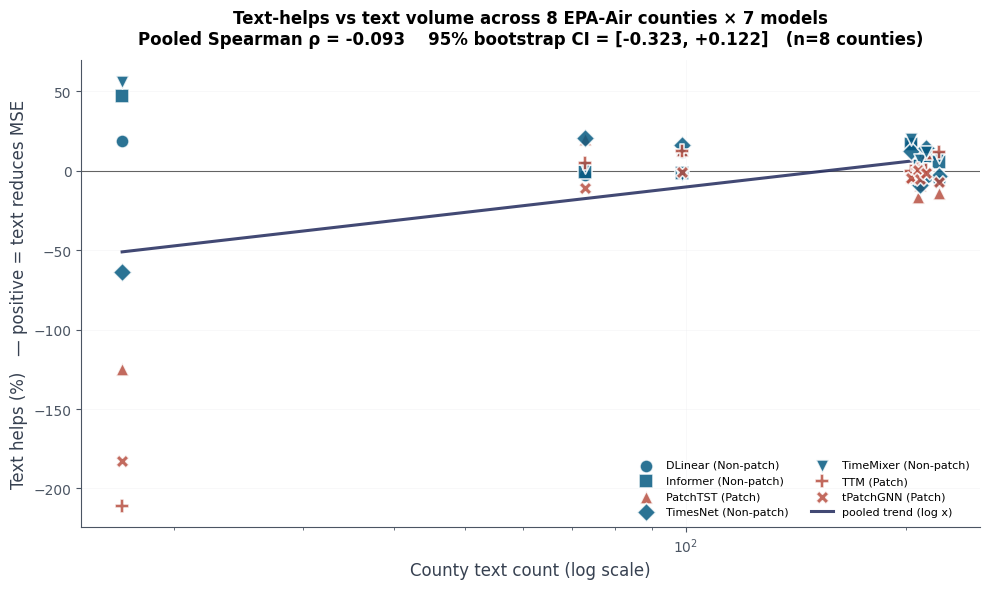

✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig11_percounty_by_family.png


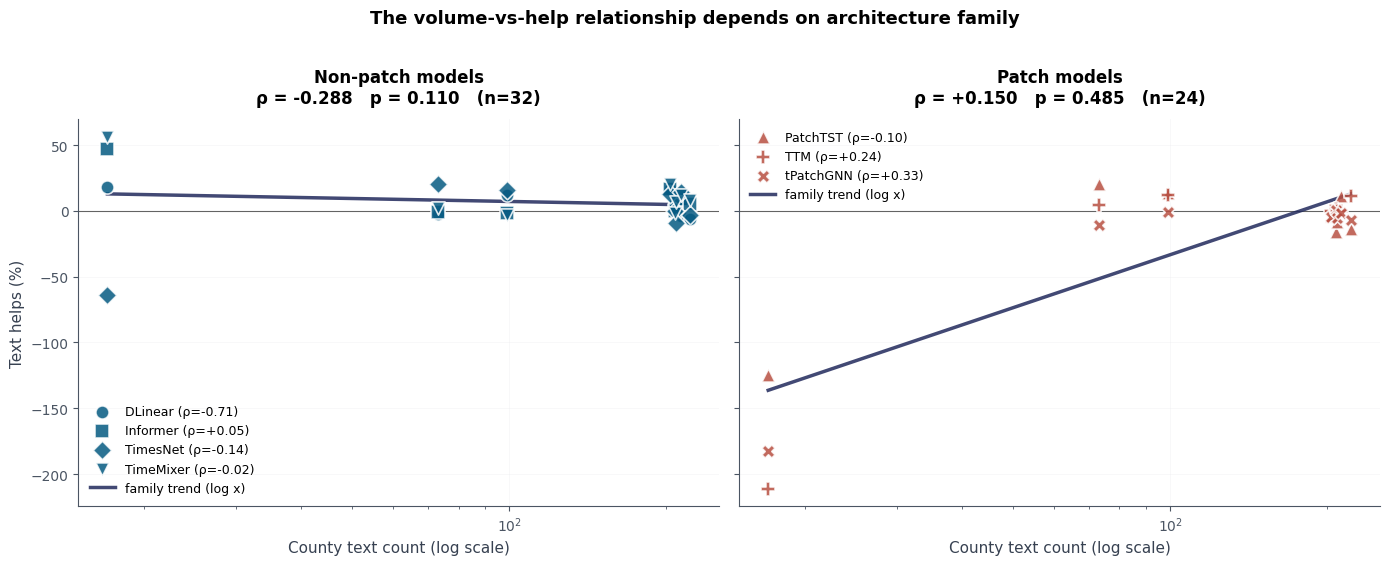


Family-level Spearman:
  Non-patch   n=32  (4 models × 8 counties)   ρ = -0.288   p = 0.110
  Patch       n=24  (3 models × 8 counties)   ρ = +0.150   p = 0.485


In [13]:
# Cell 14 — Two plots for the poster/report
import matplotlib.pyplot as plt
import numpy as np

# Architecture families (matches April-16 Ablation 2)
FAMILY = {
    'DLinear':   'Non-patch', 'Informer':  'Non-patch',
    'TimesNet':  'Non-patch', 'TimeMixer': 'Non-patch',
    'PatchTST':  'Patch',     'TTM':       'Patch',
    'tPatchGNN': 'Patch',
}
df['family'] = df['model'].map(FAMILY)

# ============================================================
# Figure 10 — Pooled view: the honest null with bootstrap CI
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

MARKERS = {'DLinear': 'o', 'Informer': 's', 'PatchTST': '^', 'TimesNet': 'D',
           'TimeMixer': 'v', 'TTM': 'P', 'tPatchGNN': 'X'}

for m in COMPLETED_MODELS:
    sub = df[df['model'] == m].sort_values('text_count')
    color = PALETTE['primary'] if FAMILY[m] == 'Non-patch' else PALETTE['warm']
    ax.scatter(sub['text_count'], sub['text_helps_pct'],
               s=90, c=color, marker=MARKERS[m],
               edgecolors='white', linewidths=1.2,
               label=f'{m} ({FAMILY[m]})', alpha=0.85, zorder=3)

# Pooled log-linear trend
xs_all = df['text_count'].values.astype(float)
ys_all = df['text_helps_pct'].values.astype(float)
z = np.polyfit(np.log(xs_all), ys_all, 1)
xf = np.linspace(xs_all.min(), xs_all.max(), 100)
ax.plot(xf, np.polyval(z, np.log(xf)),
        color=PALETTE['accent'], linewidth=2.2, alpha=0.85,
        label='pooled trend (log x)', zorder=2)

ax.axhline(0, color='black', linewidth=0.8, alpha=0.6, zorder=1)
ax.set_xscale('log')
ax.set_xlabel('County text count (log scale)', fontsize=12)
ax.set_ylabel('Text helps (%)   — positive = text reduces MSE', fontsize=12)
ax.set_title(f'Text-helps vs text volume across 8 EPA-Air counties × 7 models\n'
             f'Pooled Spearman ρ = {rho_pooled:+.3f}    '
             f'95% bootstrap CI = [{ci_lo:+.3f}, {ci_hi:+.3f}]   '
             f'(n=8 counties)',
             fontsize=12, fontweight='bold')
ax.legend(ncol=2, loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

out1 = f'{PROJECT_DIR}/results/fig10_percounty_pooled.png'
plt.tight_layout()
plt.savefig(out1, dpi=200, bbox_inches='tight', facecolor='white')
print(f'✓ Saved to {out1}')
plt.show()

# ============================================================
# Figure 11 — The family × volume split (the richer finding)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, family in zip(axes, ['Non-patch', 'Patch']):
    sub_family = df[df['family'] == family]
    models_in_family = [m for m in COMPLETED_MODELS if FAMILY[m] == family]

    for m in models_in_family:
        s = sub_family[sub_family['model'] == m].sort_values('text_count')
        ax.scatter(s['text_count'], s['text_helps_pct'],
                   s=90, marker=MARKERS[m],
                   edgecolors='white', linewidths=1.2,
                   label=f'{m} (ρ={per_model_rho[m]:+.2f})',
                   alpha=0.85, zorder=3,
                   c=PALETTE['primary'] if family == 'Non-patch' else PALETTE['warm'])

    # Family trend line
    xs = sub_family['text_count'].values.astype(float)
    ys = sub_family['text_helps_pct'].values.astype(float)
    z = np.polyfit(np.log(xs), ys, 1)
    xf = np.linspace(xs.min(), xs.max(), 100)
    ax.plot(xf, np.polyval(z, np.log(xf)),
            color=PALETTE['accent'], linewidth=2.5, alpha=0.85,
            label='family trend (log x)', zorder=2)

    rho_fam, p_fam = stats.spearmanr(xs, ys)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6, zorder=1)
    ax.set_xscale('log')
    ax.set_xlabel('County text count (log scale)', fontsize=11)
    ax.set_title(f'{family} models\n'
                 f'ρ = {rho_fam:+.3f}   p = {p_fam:.3f}   (n={len(sub_family)})',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Text helps (%)', fontsize=11)
fig.suptitle('The volume-vs-help relationship depends on architecture family',
             fontsize=13, fontweight='bold', y=1.02)

out2 = f'{PROJECT_DIR}/results/fig11_percounty_by_family.png'
plt.tight_layout()
plt.savefig(out2, dpi=200, bbox_inches='tight', facecolor='white')
print(f'✓ Saved to {out2}')
plt.show()

# Family-level statistics for the report
print('\nFamily-level Spearman:')
for family in ['Non-patch', 'Patch']:
    sub = df[df['family'] == family]
    rho, p = stats.spearmanr(sub['text_count'], sub['text_helps_pct'])
    n_models = sub['model'].nunique()
    print(f'  {family:<10}  n={len(sub)}  ({n_models} models × 8 counties)   '
          f'ρ = {rho:+.3f}   p = {p:.3f}')